In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten
#Dropout regularization:to get rig of overfitting problem
from keras.layers import Conv2D,MaxPooling2D
from keras import backend as K

Conv1D-audio ,
Conv2D-Image ,
Conv3D-Video


In [2]:
#Number of classess-do not change unless the data changes
num_classess=10

In [3]:
#sizes of batch and epoch size
batch_size=64
epochs=24

In [18]:
#input image dimension
img_rows,img_cols=28,28

In [19]:
#the data ,split into test and train
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

In [20]:
x_train.shape

(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [10]:
x_train.shape[0]

60000

In [12]:
x_train=x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test=x_test.reshape(x_test.shape[0],img_rows,img_cols,1)
input_shape=(img_rows,img_cols,1)

In [13]:
input_shape

(28, 28, 1)

In [21]:
x_train.shape

(60000, 28, 28)

In [23]:
#type converter and scale the train and test data
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train/=255.
x_test/=255.
print('x_train shape:',x_train.shape)
print('x_test shape:',x_test.shape)
print(y_train[0:3])

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
[9 0 0]


In [24]:
#convert class vectors to binary class matrices.one-hot encoding
#3=> 0 0 0 1 0 0 0 0 0 0  and 1 =>0 1 0 0 0 0 0 0 0 0
y_train=tf.keras.utils.to_categorical(y_train,num_classess)
y_test=tf.keras.utils.to_categorical(y_test,num_classess)
print(y_train[0:2])  #verify one-hot encoding

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


#CNN

In [32]:
#define the model
model=Sequential()

In [33]:
num_classess


10

In [34]:
model.add(Conv2D(32,kernel_size=(3,3),
                 activation='relu',
                 input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,kernel_size=(3,3),
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
# model.add(Dropout(0.5))
model.add(Dense(num_classess,activation='softmax'))


In [35]:
#define compile to minimize categarical loss,use some optimizer,and optimize to maximizing accuracy
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])
#Train the model and test the model with the test data after each cycle(epoch) through the training data
#Return history of loss and accuracy for each epoch
hist=model.fit(x_train,y_train,
               batch_size=64,
               epochs=24,
               verbose=1,
               validation_data=(x_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8131 - loss: 0.5134 - val_accuracy: 0.8552 - val_loss: 0.3918
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8778 - loss: 0.3342 - val_accuracy: 0.8848 - val_loss: 0.3297
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.8913 - loss: 0.2899 - val_accuracy: 0.8880 - val_loss: 0.3074
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.9023 - loss: 0.2622 - val_accuracy: 0.8915 - val_loss: 0.3084
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9113 - loss: 0.2388 - val_accuracy: 0.9016 - val_loss: 0.2769
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9183 - loss: 0.2194 - val_accuracy: 0.9021 - val_loss: 0.2698
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9240 - loss: 0.2031 - val_accuracy: 0.9035 - val_loss: 0.2601
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9304 - loss: 0.1882 - 

In [36]:
hist.history

{'accuracy': [0.8130833506584167,
  0.8777833580970764,
  0.8913000226020813,
  0.9023333191871643,
  0.9113333225250244,
  0.9182666540145874,
  0.9240166544914246,
  0.9303666949272156,
  0.9347666501998901,
  0.9407833218574524,
  0.9441666603088379,
  0.9484833478927612,
  0.9520166516304016,
  0.9574833512306213,
  0.960183322429657,
  0.963533341884613,
  0.9659666419029236,
  0.9700499773025513,
  0.9715333580970764,
  0.9729166626930237,
  0.9745333194732666,
  0.9780499935150146,
  0.9779499769210815,
  0.9801499843597412],
 'loss': [0.5134201645851135,
  0.334160715341568,
  0.2899138033390045,
  0.2621740698814392,
  0.23876018822193146,
  0.21936386823654175,
  0.20313464105129242,
  0.1882058084011078,
  0.17249010503292084,
  0.1586540788412094,
  0.14716510474681854,
  0.13642527163028717,
  0.12597814202308655,
  0.11350381374359131,
  0.10426080971956253,
  0.09775591641664505,
  0.08961153030395508,
  0.08057931065559387,
  0.07681550085544586,
  0.07131533324718475,


Test loss: 0.4638088345527649
Test accuracy: 0.9072999954223633


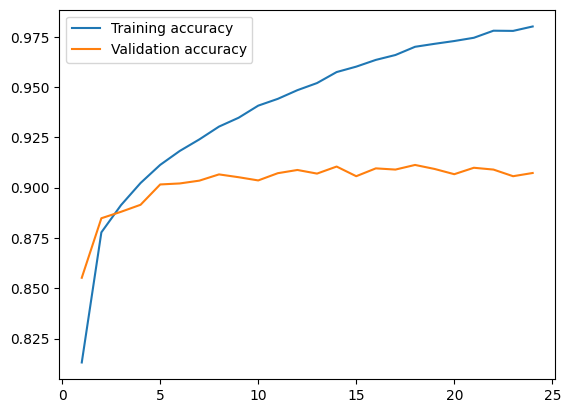

In [37]:
#Evaluvate the model with the test data to get the scores on "real" data.
score=model.evaluate(x_test,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

#plot data to see relationships in training and validation data
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
epoch_list=list(range(1,len(hist.history['accuracy'])+1))  #values for x axis [1,2,....]
plt.plot(epoch_list,hist.history['accuracy'],epoch_list,hist.history['val_accuracy'])
plt.legend(('Training accuracy','Validation accuracy'))
plt.show()
